# 1. Generating an Extended Task Graph for an edge detection application

We start with a multi-stage edge detection C/C++ application. The application processes an input RGB image into an edge-detected output image through color conversion to grayscale (`rgbToGrayscale`), multiple 2D convolutions (`convolve2d`) applying directional gradient filters, and combination/thresholding (`combthreshold`).

```c
void edge_detect(int image_rgb[H][W * 3], int image_gray[H][W], int temp_buf[H][W], int filter[K][K], int output[H][W])
{
    rgbToGrayscale(image_rgb, image_gray);
    filter[0][0] = 1;
    // ...
    filter[2][2] = 1;
    convolve2d(image_gray, filter, output);
    filter[0][0] = 1;
    // ...
    filter[2][2] = -1;
    convolve2d(output, filter, image_gray);
    filter[0][0] = 1;
    // ...
    filter[2][2] = -1;
    convolve2d(output, filter, temp_buf);
    combthreshold(image_gray, temp_buf, output);
}
```

> **Source Reference:** Full source code is available in [`../clava-scripts/CxxSources/edge_detect.cpp`](../clava-scripts/CxxSources/edge_detect.cpp).

To analyze data dependencies and expose task-level parallelism, Clava utilizes `@specs-feup/extended-task-graph` (ETG). Any developer interested in generating an ETG only needs to write a simple script like this one:

```typescript
import { ExtendedTaskGraphAPI } from "@specs-feup/extended-task-graph/ExtendedTaskGraphAPI";
import { GenFlowConfig } from "@specs-feup/extended-task-graph/GenFlowConfig";
import { SubsetTransform } from "@specs-feup/extended-task-graph/SubsetTransforms";
import { TransFlowConfig } from "@specs-feup/extended-task-graph/TransFlowConfig";

const api = new ExtendedTaskGraphAPI("edge_detect", "outputs", "edgedetect");

// 1. Code transformation flow (array flattening, constant propagation, outlining, replication)
const transConfig = new TransFlowConfig();
transConfig.transformRecipe = [
    SubsetTransform.ArrayFlattener,
    SubsetTransform.ConstantFoldingPropagation,
    SubsetTransform.StructDecomposition,
    SubsetTransform.ConstantFoldingPropagation
];
api.runCodeTransformationFlow(transConfig);

// 2. Task graph generation flow
const genConfig = new GenFlowConfig();
const etg = api.runTaskGraphGenerationFlow(genConfig);
```

### Running Clava ETG Generation
You can execute Clava directly from Python to run the code transformation and task graph generation flow. Python is used here exclusively for glueing the notebook with the JavaScript/TypeScript-based Clava framework; Python is not used at all during a typical CLI workflow:

In [6]:
import importlib
import utils
importlib.reload(utils)
from utils import run_clava

# Run Clava ETG generation flow (~20s)
run_clava()

Running Clava ETG generation flow (~20s)...


CalledProcessError: Command '['npm', 'run', 'run']' returned non-zero exit status 255.

Below is the synthesized Extended Task Graph (ETG), displaying task nodes and dataflow dependencies:

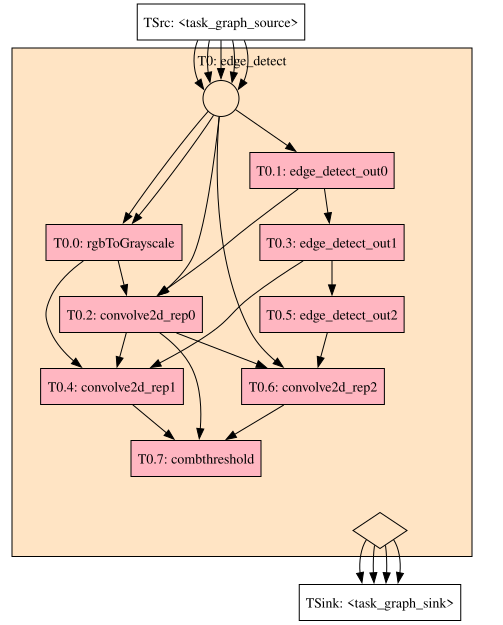

In [2]:
import importlib
import utils
importlib.reload(utils)
from utils import show_task_graph

show_task_graph()

# 2. HW/SW Partitioning of the Most Promising Task

With the task graph established, we use **Hoopa** (`@specs-feup/hoopa`) to identify the most promising acceleration candidate for FPGA offloading.

Hoopa decorates ETG tasks with Vitis HLS synthesis estimations (worst-case execution latency, resource utilization, synthesizability). Based on these estimations, the 2D convolution tasks (`convolve2d`) exhibit the highest latency (~372 ms, compared to ~62 ms for grayscale conversion and ~41 ms for thresholding).

Using the **Single Hotspot** algorithm (`HotspotCriterion.LATENCY`), Hoopa selects the highest-latency kernel (`convolve2d_rep0`), clusters it, and outlines it for hardware offloading (target: Xilinx ZCU102 FPGA). Similarly to the ETG, Hoopa also requires a very simple script to configure and call the compiler extension:

```typescript
import { BuiltinFpgaTarget } from "@specs-feup/hoopa/BuiltinFpgaPlatforms";
import { HoopaAlgorithm, HoopaConfig, OffloadingBackend, TaskGraphDecorator } from "@specs-feup/hoopa/HoopaAlgorithm";
import { HoopaAPI } from "@specs-feup/hoopa/HoopaAPI";
import { HotspotCriterion, SingleHotspotTaskOptions } from "@specs-feup/hoopa/SingleHotspotTaskOptions";
import { TimeUnit } from "@specs-feup/clava-vitis-integration/VitisReports";

const config = new HoopaConfig()
    .setTransFlowConfig(transConfig)
    .setGenFlowConfig(genConfig)
    .addDecorator(TaskGraphDecorator.VITIS_HLS)
    .addDecorator(TaskGraphDecorator.SYNTHESIZABILITY)
    .addAlgorithm(HoopaAlgorithm.SINGLE_HOTSPOT, {
        criterion: HotspotCriterion.LATENCY,
        precision: TimeUnit.MICROSECOND
    } as SingleHotspotTaskOptions)
    .addBuiltinFpgaTarget(BuiltinFpgaTarget.ZCU102);

const hoopa = new HoopaAPI("edge_detect", config, "outputs", "edgedetect");
hoopa.runFromStart(false);
```

### Running Hoopa Partitioning
Execute Hoopa directly from Python to run the latency-based single hotspot partitioning flow:

In [3]:
import importlib
import utils
importlib.reload(utils)
from utils import run_hoopa

# Run Hoopa SingleHotspot partitioning flow (~20s)
run_hoopa()

Running Hoopa HW/SW partitioning flow (~20s)...


[Hoopa-API] --------------------------------------------------------------------------------------
[Hoopa-API] ---------------------------- Starting API at 2026-09-08T09:14:09.710Z
[Hoopa-API] ---------------------------- Running Hoopa for the current AST
[Hoopa-API] --------------------------------------------------------------------------------------
[Hoopa-API] ---------------------------- Current configuration is: 
[Hoopa-API] ----------------------------  name: alg0_single_hotspot_zcu102
[Hoopa-API] ----------------------------  decorators: VitisHLS,<none>, Synthesizability,<none>
[Hoopa-API] ----------------------------  algorithm: single_hotspot
[Hoopa-API] ----------------------------  alg.options: {"criterion":"LATENCY","precision":"us"}
[Hoopa-API] ----------------------------  backends: 
[Hoopa-API] ----------------------------  target: ZCU102
[Hoopa-API] ---------------------------- Starting code transformation flow...
[Hoopa-API] ---------------------------- Code transform

Below is the partitioned task graph, with the selected hotspot task (`convolve2d_rep0`) highlighted in **green**:

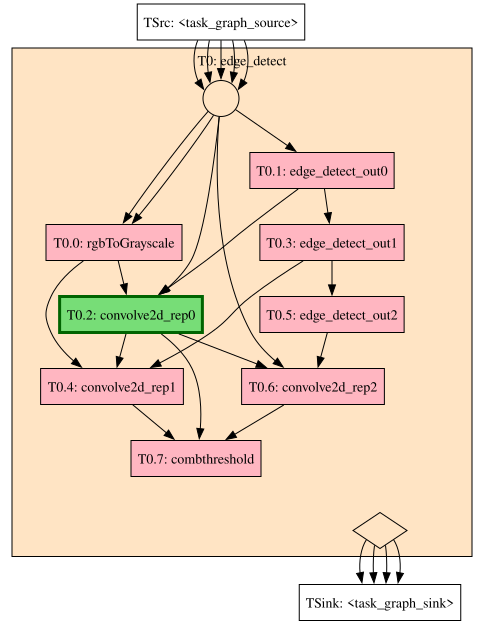

In [3]:
import importlib
import utils
importlib.reload(utils)
from utils import show_offloaded_task_graph

show_offloaded_task_graph()

# 3. Holistic HW/SW Partitioning

While offloading a single isolated hotspot (`convolve2d_rep0`) accelerates that specific operation, it introduces CPU-to-FPGA data transfer overheads across the PCIe/AXI bus and leaves the remaining convolution passes (`convolve2d_rep1` and `convolve2d_rep2`) executing sequentially on the host CPU. We can create larger, more clever regions for offloading consisting of multiple tasks, with added optimizations benefiting from the whole. We configure Hoopa to use the following:

- **CPU Profiling Annotations**: Using host CPU profiling data, Clava decorates each ETG task with its relative percentage of total execution time. In edge detection, the three convolution passes dominate execution (~24.0% each, totaling ~72.0% of compute), while grayscale conversion accounts for ~16.0% and thresholding accounts for ~4.0%.
- **Hotspot Expansion Algorithm**: Rather than stopping at an isolated kernel, the **Hotspot Expansion** algorithm (`HoopaAlgorithm.HOTSPOT_EXPANSION` with `HotspotCriterion.COMPUTATION_PERCENTAGE`) selects the dominant computation hotspot and expands the offload cluster outward to encompass adjacent pipeline tasks, aiming at achieving a cluster representing 80% of the original CPU execution time (by default).
- **Cluster Optimizations**: Offloading the entire convolution chain allows large intermediate image arrays (`image_gray`, `output`, `temp_buf`) to remain in fast FPGA-local BRAM/URAM between passes rather than bouncing back and forth across the host bus.

```typescript
import { BuiltinFpgaTarget } from "@specs-feup/hoopa/BuiltinFpgaPlatforms";
import { HoopaAlgorithm, HoopaConfig, OffloadingBackend, TaskGraphDecorator } from "@specs-feup/hoopa/HoopaAlgorithm";
import { HoopaAPI } from "@specs-feup/hoopa/HoopaAPI";
import { HotspotCriterion } from "@specs-feup/hoopa/SingleHotspotTaskOptions";
import { HotspotExpansionOptions } from "@specs-feup/hoopa/HotspotExpansionOptions";
import { TimeUnit } from "@specs-feup/clava-vitis-integration/VitisReports";

const config = new HoopaConfig()
    .setTransFlowConfig(transConfig)
    .setGenFlowConfig(genConfig)
    .addDecorator(TaskGraphDecorator.VITIS_HLS)
    .addDecorator(TaskGraphDecorator.SYNTHESIZABILITY)
    .addDecorator(TaskGraphDecorator.PROFILING, "gprof-zcu102")
    .addAlgorithm(HoopaAlgorithm.HOTSPOT_EXPANSION, {
        hotspotCriterion: HotspotCriterion.COMPUTATION_PERCENTAGE,
        profiler: "gprof-zcu102",
        precision: TimeUnit.MICROSECOND,
        policies: [],
        hlsSynthesis: false
    } as HotspotExpansionOptions)
    .addBuiltinFpgaTarget(BuiltinFpgaTarget.ZCU102);

const hoopa = new HoopaAPI("edge_detect", config, "outputs", "edgedetect");
hoopa.runFromStart(false);
```

### Running Holistic Hotspot Expansion
Execute Hoopa directly from Python to run the Hotspot Expansion algorithm with CPU profiling annotations:

In [5]:
import importlib
import utils
importlib.reload(utils)
from utils import run_hotspot_expansion

# Run Hoopa Hotspot Expansion flow (~25s)
run_hotspot_expansion()

Running Hoopa Hotspot Expansion flow (~25s)...


[Hoopa-API] --------------------------------------------------------------------------------------
[Hoopa-API] ---------------------------- Starting API at 2026-09-08T09:14:45.396Z
[Hoopa-API] ---------------------------- Running Hoopa for the current AST
[Hoopa-API] --------------------------------------------------------------------------------------
[Hoopa-API] ---------------------------- Current configuration is: 
[Hoopa-API] ----------------------------  name: alg0_hotspot_expansion_zcu102
[Hoopa-API] ----------------------------  decorators: VitisHLS,<none>, Synthesizability,<none>, Profiling,gprof-zcu102
[Hoopa-API] ----------------------------  algorithm: hotspot_expansion
[Hoopa-API] ----------------------------  alg.options: {"hotspotCriterion":"COMPUTATION_PERCENTAGE","profiler":"gprof-zcu102","precision":"us","policies":[],"hlsSynthesis":false}
[Hoopa-API] ----------------------------  backends: 
[Hoopa-API] ----------------------------  target: ZCU102
[Hoopa-API] --------

Below is the synthesized ETG with CPU profiling annotations (percentage of total execution time) displayed on each task node, and the expanded offloaded tasks (the three outlined filter-setup tasks `edge_detect_out0/1/2`, the three convolution passes `convolve2d_rep0/1/2`, and `combthreshold`) highlighted in **green**:


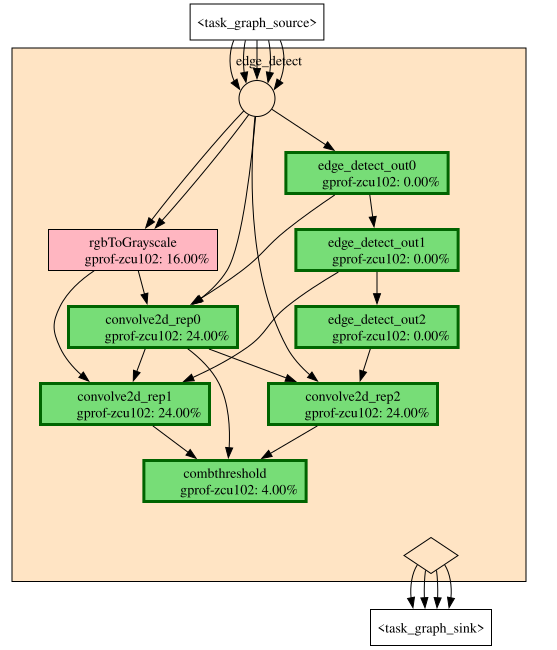

In [4]:
import importlib
import utils
importlib.reload(utils)
from utils import show_expanded_task_graph

show_expanded_task_graph()

# 4. Partitioning Trade-Off & Resource Analysis

Comparing the two partitioning strategies highlights the fundamental trade-offs in HW/SW co-design based on the updated HLS synthesis reports on the Xilinx ZCU102 FPGA. Key takeaways:

1. **End-to-End Application Latency & Amdahl's Law**: Baseline CPU execution time is 337.0 ms (310.0 ms for 92% computation plus 27.0 ms for the 8% file I/O region, which is non-accelerable and fixed across all strategies). Offloading only the single hotspot task (`convolve2d_rep0`) achieves a modest 1.15× speedup (293.8 ms total), because 76% of compute remains on the CPU. Holistic hotspot expansion offloads 76.0% of computation into an optimized hardware pipeline running in 48.57 ms, bringing total execution time down to 149.9 ms (**2.25× speedup**). Notice how the fixed 27.0 ms I/O grows from 8.0% to 18.0% of the overall runtime, illustrating Amdahl's Law.
2. **Buffer Internalization**: In the expanded cluster, intermediate image buffers (`filter`, `temp_buf`) are localized directly within the hardware function. This leverages 468 BRAM_18K blocks to store image frames across convolution and thresholding passes, keeping general logic usage minimal (only 4.2% LUT and 2.1% FF) while eliminating DMA round-trips.

The chart below presents the end-to-end application latency breakdown (left) with 3-segment split bars (FPGA HW time, Host CPU compute, and non-accelerable I/O), alongside FPGA resource utilization (right) with separated grouped bars.

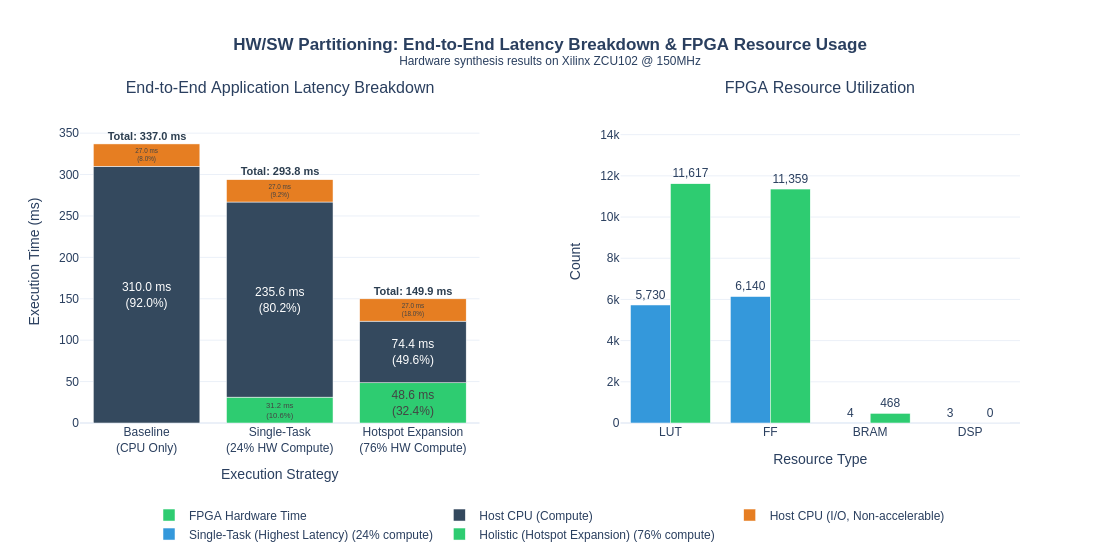

In [5]:
import importlib
import utils
importlib.reload(utils)

# Render interactive trade-off dashboard (Plotly)
utils.plot_partitioning_comparison(interactive=True)